<pre>
#evaluating the facenet model on the lfw dataset on different thresholds.
#I will be using matchpairsdevtrain and mismatchpairsdevtrain to evaluate the model and test the model using devtest.
#First, I will load the facenet model and the lfw dataset.
#second, I will compute embeddings of the images of devtrain and devtest.
#third, I will compute the distances between the embeddings of the pairs in the matchpairsdevtrain and mismatchpairsdevtrain then find the best threshold that gives the best accuracy.
#Finally, I will test the model on devtest using the best threshold and compute the accuracy.


In [1]:
from pathlib import Path
from PIL import Image
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from facenet_pytorch import InceptionResnetV1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#define the transforms
transform = v2.Compose([
    v2.Resize((160,160)),
    v2.ToTensor(),
    v2.Normalize([0.5]*3, [0.5]*3)
]
)

e:\learning_pytorch\venv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [3]:
#get the match and mismatch pairs list
match_pairs = pd.read_csv("../../datasets/matchpairsDevTrain.csv")
mismatch_pairs = pd.read_csv("../../datasets/mismatchpairsDevTrain.csv")
match_pairs_test = pd.read_csv("../../datasets/matchpairsDevTest.csv")
mismatch_pairs_test = pd.read_csv("../../datasets/mismatchpairsDevTest.csv")
root_dir = Path("../../datasets/lfw-deepfunneled")

In [4]:
match_pairs.head(5)

,name,imagenum1,imagenum2
0,Aaron_Peirsol,1,2
1,Aaron_Peirsol,3,4
2,Aaron_Sorkin,1,2
3,Abdel_Nasser_Assidi,1,2
4,Abdullah,1,3


In [5]:
len(match_pairs)

1100

In [6]:
mismatch_pairs.head(5)

,name,imagenum1,name.1,imagenum2
0,AJ_Cook,1,Marsha_Thomason,1
1,Aaron_Sorkin,2,Frank_Solich,5
2,Abdel_Nasser_Assidi,2,Hilary_McKay,1
3,Abdoulaye_Wade,4,Linda_Dano,1
4,Abdul_Rahman,1,Magui_Serna,1


In [7]:
model = InceptionResnetV1(pretrained="vggface2").eval()

In [8]:
#image to embeddings
def img_emb(img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img)
    with torch.no_grad():
        emb = model(img.unsqueeze(0))
        
    return emb

In [9]:
#get the image path
def get_img_path(name, index):
    return root_dir/ f"lfw-deepfunneled/{name}/{name}_{index:04d}.jpg"

In [10]:
name, im1, im2 = match_pairs.iloc(0)[0]

In [11]:
get_img_path(name, im1)

WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0001.jpg')

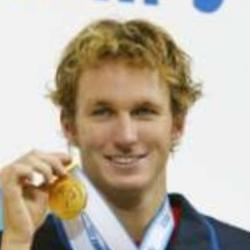

In [12]:
Image.open(get_img_path(name, im1))

In [13]:
#load the images
def lfw_pair_ds(match_pairs, mismatch_pairs):
    pairs = []
    for _, row in match_pairs.iterrows():
        name = row.iloc[0]
        index1 = int(row.iloc[1])
        index2 = int(row.iloc[2])
        img1 = get_img_path(name, index1)
        img2 = get_img_path(name, index2)
        pairs.append((img1, img2, 1))
        
    for _, row in mismatch_pairs.iterrows():
        name1 = row.iloc[0]
        index1 = int(row.iloc[1])
        name2 = row.iloc[2]
        index2 = int(row.iloc[3])
        img1 = get_img_path(name1, index1)
        img2 = get_img_path(name2, index2)
        pairs.append((img1, img2, 0))
        
    return pairs

In [14]:
#convert the images to embeddings
pairs = lfw_pair_ds(match_pairs, mismatch_pairs)
test_pairs = lfw_pair_ds(match_pairs_test, mismatch_pairs_test)

In [15]:
print("length of pairs: ", len(pairs))
print("lenght of test_pairs: ", len(test_pairs))

length of pairs:  2200
lenght of test_pairs:  1000


In [16]:
pairs[:3]

[(WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0001.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0002.jpg'),
  1),
 (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0003.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0004.jpg'),
  1),
 (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Sorkin/Aaron_Sorkin_0001.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Sorkin/Aaron_Sorkin_0002.jpg'),
  1)]

In [17]:
test_pairs[-4:-1]

[(WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Takeo_Fukui/Takeo_Fukui_0001.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Will_Ofenheusle/Will_Ofenheusle_0001.jpg'),
  0),
 (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Tamara_Mowry/Tamara_Mowry_0001.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Zach_Parise/Zach_Parise_0001.jpg'),
  0),
 (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Tatiana_Kennedy_Schlossberg/Tatiana_Kennedy_Schlossberg_0001.jpg'),
  WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Thomas_Watjen/Thomas_Watjen_0001.jpg'),
  0)]

In [18]:
#get the unqiue images to calculate the embeddings of all the images at once
unique_imgs = set()

for img1, img2, _ in pairs:
    unique_imgs.add(img1)
    unique_imgs.add(img2)
    
for img1, img2, _ in test_pairs:
    unique_imgs.add(img1)
    unique_imgs.add(img2)

In [19]:
len(unique_imgs)

4992

In [20]:
emb_cache = {}
for path in unique_imgs:
    emb = img_emb(path)
    emb_cache[path] = emb

In [21]:
#evaluating the dataset
def evaluate(pairs, emb_cache, threshold):
    correct = 0
    total = 0
    for img1, img2, label in pairs:
        emb1 = emb_cache[img1]
        emb2 = emb_cache[img2]
        
        dist = torch.norm(emb1 - emb2).item()
        
        pred = 1 if dist < threshold else 0
        
        if pred == label:
            correct += 1
        total += 1
        
    accuracy = correct/total
    return accuracy
        

In [22]:
accuracy = []
thresholds = np.arange(0.5, 1.5, 0.1)
print("evaluating:")
for threshold in thresholds:
    acc = evaluate(pairs, emb_cache, threshold)
    accuracy.append(acc)

evaluating:


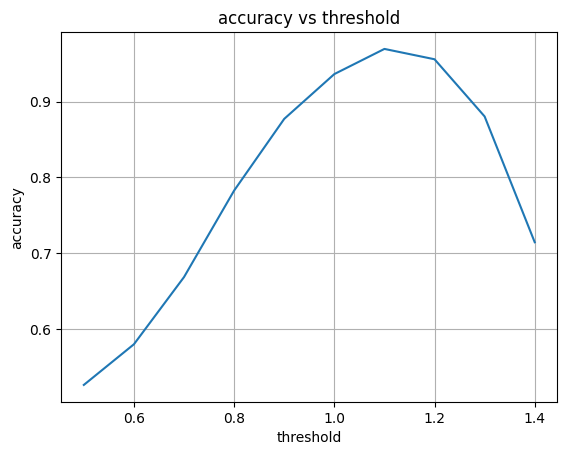

In [23]:
plt.plot(thresholds, accuracy)
plt.xlabel("threshold")
plt.ylabel("accuracy")
plt.title("accuracy vs threshold")
plt.grid(True)
plt.show()

In [24]:
thresholds

array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4])

In [25]:
np.isclose(thresholds, 1.2)

array([False, False, False, False, False, False, False,  True, False,
       False])

In [26]:
index = np.argmax(accuracy)
acc_final = accuracy[index]
threshold_final = thresholds[index]
print(f"accuracy of the model at threshold = {np.round(threshold_final, 2)} is {acc_final * 100}")

accuracy of the model at threshold = 1.1 is 96.95454545454545


### testing the dataset on devtest set

In [27]:
test_accuracy = evaluate(test_pairs, emb_cache, threshold_final)
print("test accuracy of the model is: ", test_accuracy * 100, "%")

test accuracy of the model is:  96.3 %


In [28]:
import pickle
save_path = "../../saved_models/facenet_embs.pkl"
with open(save_path, "wb") as f:
    pickle.dump(emb_cache, f)

### Things i learned from this notebook:
* You need to thoroughly understand the dataset and the problem you are trying to solve before you start coding.
* Select the right model architecture and a proper framerwork for your problem, in this case, I chose FaceNet framework and InceptionResNetV1 model architecture.
* Preprocessing the data is most important, this lfw dataset already comes preprocessed i.e. faces aligned and cropped else i would have to use MTCNN to detect and align the faces.
* This model uses triplet loss function which needs the images to be in pairs and it was good that i already had matchpairsdevtrain and mismatchpairsdevtrain to evaluate the model and find the best threshold.
#### programming tips from this notebook:
* always start with transform and dataloader to make sure your data is in the right format and you can easily feed it to the model.
* write functions for each operation and write them at once, then after writing all the operations you can just call them, which preserves the flow of the code and makes it more readable.
* prefer classes over functions, it is more organized and easier to maintain.